# Train a "products in a room" LoRA on Stable Diffusion 1.5 (Google Colab)

**What this does.** Fine-tunes Stable Diffusion 1.5 with a **LoRA** — a small add-on (a few MB) trained on top of the
frozen base model — using your supplier product photos. Each photo has its white studio background removed and is pasted
into a randomly generated room, and captioned from its folder name ("Halo Nightstand ... in a bedroom"), so the model
learns what *your pieces* look like inside rooms. Afterwards it generates room images with the LoRA switched on and
compares them with the plain model.

**What to expect (honest version).** The LoRA learns the *look* of the catalogue — shapes, materials, finishes — and will
draw pieces in that style inside rooms. It will **not** reproduce one exact product photo-perfectly, and the training
rooms are simple procedural backdrops, so treat outputs as concept previews. For exact real products in a room the
composite renderer is still more faithful.

## How to run it
1. Colab: **Runtime → Change runtime type → T4 GPU**.
2. Put your image folder in Google Drive (same structure you have now: `ATRIANI/`, `CELADON/`, `LAZZONI/` (PDFs), `LUXUS/`...).
3. Leave `DRIVE_IMAGES_DIR = "auto"` in the **CONFIG** cell: it searches your My Drive and every shared drive you can
   see for the folder that contains the supplier subfolders (`LUXUS`, `CELADON`, ...), so you do not need the exact path.
   To point at a folder yourself instead, use `/content/drive/MyDrive/<folder>` or
   `/content/drive/Shareddrives/<Shared drive name>/<folder>`. (A folder under **"Shared with me"** only appears after
   you right-click it → *Organize → Add shortcut* into My Drive.) Use the *same Google account* for Colab that has
   access to the shared drive.
4. **Run all.** Colab asks permission to mount Drive. Training runs about 20–40 minutes on a free T4 (an estimate — not measured).
5. The trained LoRA is written to `DRIVE_OUTPUT_DIR` in your Drive (plus a `.zip` for download). A checkpoint is saved every
   few hundred steps, so if Colab disconnects you keep the latest one.

The notebook also runs locally if you have an NVIDIA GPU; it stops with a clear message if there is none. Non-image files
(PDFs, `.DS_Store`, spreadsheets), unreadable images and tiny thumbnails are **skipped and reported**, never fatal.


In [1]:
# ============================== CONFIG: edit these ==============================
# Where the images are. In Colab these are Google Drive paths; locally the LOCAL_* paths are used.
DRIVE_IMAGES_DIR = "/content/drive/MyDrive/Curalina - Humber Capstone/Supplier Images"   # "auto" = search your Drive + shared drives for the supplier folders.
#                             e.g. "/content/drive/Shareddrives/<Drive name>/<folder>" or "/content/drive/MyDrive/<folder>"
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/curalina_lora_output"   # the trained model is written here

LOCAL_IMAGES_DIR = "/Users/rjsalmon/Documents/Humber/misc.curalina/Supplier Images"
LOCAL_OUTPUT_DIR = "./lora_output"

# Model + training settings
BASE_MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"
TRIGGER = "crlnstyle"          # rare word the LoRA learns to associate with the catalogue look
RESOLUTION = 512
MAX_TRAIN_STEPS = 1200         # optimizer steps
BATCH_SIZE = 2
LEARNING_RATE = 1e-4
LORA_RANK = 8
SAVE_EVERY = 400               # checkpoint to Drive every N steps
GRADIENT_CHECKPOINTING = True  # slower, but avoids out-of-memory on a free T4
P_ROOM_BACKGROUND = 0.8        # share of training samples pasted into a synthetic room (rest: plain product photo)
MIN_SIDE_PX = 200              # skip thumbnails smaller than this
SEED = 42

# Debug: set to a small number (e.g. 20) to try the pipeline on a few images first, or None for everything.
LIMIT_IMAGES = None

In [2]:
import os, sys, json, random, math, shutil, re, time, difflib
from pathlib import Path
from collections import Counter

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")


def explain_missing(path: Path) -> str:
    # Finds the deepest folder that DOES exist, lists what is in it, and suggests the closest spelling.
    p = Path(path)
    missing = []
    while not p.exists() and p != p.parent:
        missing.insert(0, p.name)
        p = p.parent
    try:
        children = sorted(os.listdir(p))
    except OSError:
        children = []
    msg = f"'{path}' was not found.\nThe part that exists is: {p}\nThe first name that is missing is: '{missing[0] if missing else ''}'\n"
    msg += f"Folders that DO exist inside {p}:\n  " + ("\n  ".join(children[:40]) if children else "(none - is this the Google account that has access?)") + "\n"
    if missing and children:
        close = difflib.get_close_matches(missing[0], children, n=3, cutoff=0.4)
        if close:
            msg += f"Did you mean: {close}\n"
    msg += "Tip: in Colab open the Files panel (folder icon, left), browse to the folder, right-click -> Copy path, and paste it into the CONFIG cell."
    return msg


SUPPLIER_MARKERS = {"atriani", "celadon", "lazzoni", "luxus"}


def find_images_root(max_depth: int = 5):
    # Looks through every shared drive and My Drive for a folder that contains at least two of the supplier folders.
    roots = []
    shared = Path("/content/drive/Shareddrives")
    if shared.is_dir():
        roots += [shared / d for d in sorted(os.listdir(shared))]
    roots.append(Path("/content/drive/MyDrive"))
    hits = []
    for base in roots:
        base_parts = len(base.parts)
        for cur, dirs, _ in os.walk(base):
            depth = len(Path(cur).parts) - base_parts
            dirs[:] = [d for d in dirs if not d.startswith(".")] if depth < max_depth else []
            if len({d.lower() for d in dirs} & SUPPLIER_MARKERS) >= 2:
                hits.append(Path(cur))
                dirs[:] = []                       # found it; do not search inside
    return hits


if IN_COLAB:
    # Uncomment if a package is missing. Colab already has torch/torchvision.
    # !pip -q install diffusers transformers accelerate peft
    from google.colab import drive
    drive.mount("/content/drive",force_remount=True)
    for root in ["/content/drive", "/content/drive/Shareddrives", "/content/drive/MyDrive"]:
        print(f"{root} ->", sorted(os.listdir(root))[:30] if os.path.isdir(root) else "(not found)")

    # Make sure to run the CONFIG cell (cell b568965d) first to set DRIVE_IMAGES_DIR correctly!
    print(f"DEBUG (Cell 6f9d2616): DRIVE_IMAGES_DIR is '{DRIVE_IMAGES_DIR}'")

    if DRIVE_IMAGES_DIR.strip().lower() == "auto":
        print("Searching your Drive for the supplier image folders (looks for LUXUS / CELADON / ATRIANI / LAZZONI)...")
        hits = find_images_root()
        if len(hits) == 1:
            IMAGES_DIR = hits[0]
            print("Found:", IMAGES_DIR)
        elif len(hits) > 1:
            raise SystemExit("Found several candidate folders - copy one into DRIVE_IMAGES_DIR:\n  " + "\n  ".join(map(str, hits)))
        else:
            raise SystemExit("Could not find a folder containing LUXUS / CELADON / ATRIANI / LAZZONI anywhere in your Drive.\n"
                             "Check you mounted the Google account that has access, and that the shared drive is listed above.")
    else:
        IMAGES_DIR = Path(DRIVE_IMAGES_DIR)
    OUTPUT_DIR = Path(DRIVE_OUTPUT_DIR)
    WORK_DIR = Path("/content/work")

else:
    IMAGES_DIR = Path(LOCAL_IMAGES_DIR)
    OUTPUT_DIR = Path(LOCAL_OUTPUT_DIR)
    WORK_DIR = Path("./work")

# Check the input folder FIRST, with a readable message, before creating anything.
print(f"DEBUG (Cell 6f9d2616): IMAGES_DIR is '{IMAGES_DIR}' before checking existence.")
if not IMAGES_DIR.is_dir():
    raise SystemExit("IMAGE FOLDER PROBLEM\n" + explain_missing(IMAGES_DIR))

Mounted at /content/drive
/content/drive -> ['.Encrypted', '.Trash-0', '.shortcut-targets-by-id', 'MyDrive']
/content/drive/Shareddrives -> (not found)
/content/drive/MyDrive -> ['Colab Notebooks', 'Curalina - Humber Capstone']
DEBUG (Cell 6f9d2616): DRIVE_IMAGES_DIR is '/content/drive/MyDrive/Curalina - Humber Capstone/Supplier Images'
DEBUG (Cell 6f9d2616): IMAGES_DIR is '/content/drive/MyDrive/Curalina - Humber Capstone/Supplier Images' before checking existence.


## 1. Find the images (and skip everything else)

We walk the whole folder tree. Only these extensions are treated as images; anything else — the Lazzoni PDFs,
`.DS_Store`, spreadsheets — is counted and skipped. Then every candidate is opened once with Pillow: files that are
corrupt, unreadable or smaller than `MIN_SIDE_PX` are dropped and listed, so training never hits a bad file.


In [3]:
import pandas as pd
from PIL import Image, UnidentifiedImageError

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp"}
Image.MAX_IMAGE_PIXELS = 60_000_000  # guard against decompression bombs

found, skipped_non_image = [], Counter()
for root, dirs, files in os.walk(IMAGES_DIR):
    dirs[:] = [d for d in dirs if not d.startswith(".")]
    for name in files:
        if name.startswith("."):
            continue
        p = Path(root) / name
        ext = p.suffix.lower()
        if ext in IMAGE_EXTS:
            found.append(p)
        else:
            skipped_non_image[ext or "(no extension)"] += 1

print(f"{len(found)} candidate image files")
print("skipped non-image files by type:", dict(skipped_non_image) or "none")

valid, rejected = [], []
for p in sorted(found):
    try:
        with Image.open(p) as im:
            im.verify()                      # cheap integrity check
        with Image.open(p) as im:            # verify() invalidates the handle, reopen for size
            w, h = im.size
        if min(w, h) < MIN_SIDE_PX:
            rejected.append((str(p.relative_to(IMAGES_DIR)), f"too small ({w}x{h})"))
        else:
            valid.append(p)
    except (UnidentifiedImageError, OSError, ValueError, Image.DecompressionBombError) as e:
        rejected.append((str(p.relative_to(IMAGES_DIR)), f"unreadable: {type(e).__name__}"))

if LIMIT_IMAGES:
    random.Random(SEED).shuffle(valid)
    valid = sorted(valid[:LIMIT_IMAGES])

print(f"{len(valid)} usable images, {len(rejected)} rejected")
pd.DataFrame(rejected, columns=["file", "reason"]).head(15)


191 candidate image files
skipped non-image files by type: {'.pdf': 33}
144 usable images, 47 rejected


,file,reason
0,CELADON/007 - Cafe Au Lait Diptych - 21339/Caf...,too small (234x143)
1,LUXUS/Product Images/002 - Accord Side Table/0...,too small (157x311)
2,LUXUS/Product Images/002 - Accord Side Table/0...,too small (117x254)
3,LUXUS/Product Images/002 - Accord Side Table/0...,too small (106x282)
4,LUXUS/Product Images/005 - Adana Sofa/02 - Ada...,too small (273x148)
5,LUXUS/Product Images/005 - Adana Sofa/03 - Ada...,too small (113x132)
6,LUXUS/Product Images/006 - Allure Side Table/0...,too small (174x284)
7,LUXUS/Product Images/008 - Andros Slim Sofa/01...,too small (553x193)
8,LUXUS/Product Images/010 - Arcadia Dining Tabl...,too small (286x120)
9,LUXUS/Product Images/020 - Buriti Corner table...,too small (123x131)


## 2. Captions from the folder structure

Supplier = the top-level folder (`LUXUS`, `CELADON`, ...). Product name = the folder the image sits in, with the
`001 - ` numbering and any trailing SKU removed. A keyword pass maps names to a furniture category and a sensible room
(a bed goes in a bedroom, a dining chair in a dining room). Nothing here needs the spreadsheets.


In [4]:
CATEGORY_RULES = [  # first match wins; (category, regex, rooms it belongs in)
    ("dining chair", r"dining chair", ["dining room"]),
    ("dining table", r"dining table", ["dining room"]),
    ("accent chair", r"accent chair|armchair|lounge chair|poltrona|chair", ["living room", "bedroom"]),
    ("coffee table", r"coffee table|cocktail table", ["living room"]),
    ("side table", r"side table|end table", ["living room", "bedroom"]),
    ("bar cabinet", r"bar cabinet", ["dining room", "living room"]),
    ("sectional sofa", r"sectional|modular", ["living room"]),
    ("sofa", r"\bsofa\b|\bloveseat\b", ["living room"]),
    ("ottoman", r"ottoman", ["living room"]),
    ("bench", r"\bbench\b", ["bedroom", "living room"]),
    ("nightstand", r"night ?stand|bedside", ["bedroom"]),
    ("bed", r"\bbed\b|\bking\b|\bqueen\b", ["bedroom"]),
    ("sideboard", r"sideboard|buffet|credenza", ["dining room", "living room"]),
    ("table", r"table", ["dining room", "living room"]),
    ("console or cabinet", r"console|media|cabinet|shelf|bookcase|vanity|desk|stool", ["living room", "dining room"]),
]


def clean_name(folder_name: str) -> str:
    n = re.sub(r"^\s*\d+\s*-\s*", "", folder_name)          # "001 - Halo Nightstand" -> "Halo Nightstand"
    n = re.sub(r"\s*-\s*\d{4,}\s*$", "", n)                # Celadon "Traverse I - 21368" -> "Traverse I"
    n = n.replace("_", ":").strip()
    return n or folder_name


def describe(path: Path):
    rel = path.relative_to(IMAGES_DIR)
    parts = rel.parts
    supplier = parts[0] if len(parts) > 1 else "unknown"
    folder = parts[-2] if len(parts) > 2 else path.stem        # product folder; fall back to file name
    if folder.lower() in {"product images", supplier.lower()}:
        folder = path.stem
    name = clean_name(folder)
    if supplier.upper() == "CELADON":
        return dict(supplier=supplier, name=name, category="framed wall art", rooms=["living room", "bedroom"], is_art=True)
    for category, pattern, rooms in CATEGORY_RULES:
        if re.search(pattern, name.lower()):
            return dict(supplier=supplier, name=name, category=category, rooms=rooms, is_art=False)
    return dict(supplier=supplier, name=name, category="piece of furniture", rooms=["living room"], is_art=False)


records = []
for p in valid:
    d = describe(p)
    d["path"] = str(p)
    records.append(d)

df = pd.DataFrame(records)
print(df.groupby(["supplier", "category"]).size().to_string())
df[["supplier", "name", "category"]].sample(min(8, len(df)), random_state=SEED)


supplier  category          
CELADON   framed wall art       61
LUXUS     accent chair          22
          bed                    5
          bench                  2
          coffee table           8
          nightstand             6
          ottoman                6
          piece of furniture     7
          side table             6
          sideboard              4
          sofa                  16
          table                  1


,supplier,name,category
117,LUXUS,Maria Sideboard,sideboard
19,CELADON,Stratum Diptych,framed wall art
82,LUXUS,Buriti Sofa,sofa
97,LUXUS,Elysian Accent Chair,accent chair
56,CELADON,Edifice Series; Black and Tan II,framed wall art
12,CELADON,Botanical in Umber I,framed wall art
132,LUXUS,Sogno Nightstand Mauricio Borin,nightstand
65,LUXUS,Adana Sofa,sofa


## 3. Cut out the products and build "product in a room" training images

Studio photos have a white background, which would teach the model "furniture floats on white". So we **remove the
background** (flood-fill from the image border — white areas *inside* the product, like a white sofa, are kept) and paste
the cutout into a randomly generated room: random wall colour, floor, baseboard, sometimes a window, with a soft shadow.
Artwork is hung on the wall instead of placed on the floor. Cutouts are cached in `WORK_DIR`.


In [5]:
import numpy as np
from PIL import ImageDraw, ImageFilter

CUTOUT_DIR = WORK_DIR / "cutouts"
CUTOUT_DIR.mkdir(parents=True, exist_ok=True)


def matte_white_background(img: Image.Image, tolerance: int = 45, max_side: int = 640) -> Image.Image:
    rgba = img.convert("RGBA")
    if max(rgba.size) > max_side:
        rgba.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
    flat = Image.alpha_composite(Image.new("RGBA", rgba.size, (255, 255, 255, 255)), rgba).convert("RGB")
    work = flat.copy()
    w, h = work.size
    marker = (255, 0, 255)
    floor = 255 - tolerance
    for seed in [(0, 0), (w - 1, 0), (0, h - 1), (w - 1, h - 1), (w // 2, 0), (w // 2, h - 1), (0, h // 2), (w - 1, h // 2)]:
        px = flat.getpixel(seed)
        if all(int(c) >= floor for c in px[:3]):
            ImageDraw.floodfill(work, seed, marker, thresh=tolerance)
    arr = np.array(rgba)
    background = np.all(np.array(work) == np.array(marker), axis=2)
    arr[..., 3][background] = 0
    arr[..., 3][arr[..., 3] < 40] = 0
    alpha = Image.fromarray(arr[..., 3]).filter(ImageFilter.MinFilter(3))   # erode 1px: drops the white fringe
    arr[..., 3] = np.array(alpha)
    return Image.fromarray(arr, "RGBA")


SKIP_REASONS = Counter()
SWATCH_NAME = re.compile(r"^(l\d+|ai\d+)\b", re.I)   # finish/material swatch files like "L139.png", "AI01- Chrome.webp"


def build_cutout(path: str, is_art: bool):
    # Returns the cached cutout path, or None (and counts why) if the image is not a usable product photo.
    p = Path(path)
    if SWATCH_NAME.match(p.stem):
        SKIP_REASONS["finish swatch (by file name)"] += 1
        return None
    out = CUTOUT_DIR / (re.sub(r"[^A-Za-z0-9]+", "_", str(p.relative_to(IMAGES_DIR))) + ".png")
    if out.exists():
        return str(out)
    try:
        with Image.open(p) as im:
            cut = matte_white_background(im)
        alpha = np.array(cut)[..., 3]
        visible = (alpha > 127).mean()
        if visible < 0.02:
            SKIP_REASONS["almost all background"] += 1
            return None
        if not is_art and visible > 0.93:
            SKIP_REASONS["no studio background (swatch / close-up)"] += 1
            return None
        rgb = np.array(cut.convert("RGB")).astype(float)
        if not is_art and rgb[alpha > 127].mean() > 240:      # mostly white pixels: a line drawing, not a photo
            SKIP_REASONS["line drawing (white on white)"] += 1
            return None
        cut.crop(cut.getchannel("A").getbbox()).save(out)
        return str(out)
    except Exception as e:                        # never let one bad file stop the run
        SKIP_REASONS[f"error: {type(e).__name__}"] += 1
        return None


t0 = time.time()
df["cutout"] = [build_cutout(p, a) for p, a in zip(df["path"], df["is_art"])]
before = len(df)
df = df[df["cutout"].notna()].reset_index(drop=True)      # only clean product cutouts are trained on
print(f"{len(df)}/{before} images kept after cutout ({time.time() - t0:.0f}s). Dropped: {dict(SKIP_REASONS) or 'none'}")

WALLS = [(236, 231, 222), (222, 214, 200), (205, 210, 205), (196, 187, 175), (233, 224, 214),
         (94, 98, 96), (58, 56, 60), (170, 150, 128), (215, 220, 224)]
FLOORS = [(176, 140, 100), (140, 105, 75), (205, 190, 165), (95, 80, 70), (160, 150, 140), (60, 55, 52)]


def make_room_background(rng: random.Random, size: int = 512):
    wall, floor = rng.choice(WALLS), rng.choice(FLOORS)
    horizon = int(size * rng.uniform(0.58, 0.68))
    img = Image.new("RGB", (size, size), wall)
    d = ImageDraw.Draw(img)
    d.rectangle([0, horizon, size, size], fill=floor)
    d.rectangle([0, horizon - 10, size, horizon], fill=tuple(min(255, c + 25) for c in wall))   # baseboard
    if rng.random() < 0.5:                                                                      # window
        x0 = rng.randint(int(size * 0.08), int(size * 0.55)); w = rng.randint(90, 150)
        d.rectangle([x0, int(size * 0.12), x0 + w, horizon - 60], fill=(250, 250, 244), outline=(120, 120, 110), width=4)
    grad = np.linspace(1.06, 0.92, size)[:, None, None]
    return Image.fromarray(np.clip(np.array(img) * grad, 0, 255).astype("uint8")), horizon


def compose_room_sample(cut: Image.Image, is_art: bool, rng: random.Random, size: int = 512):
    bg, horizon = make_room_background(rng, size)
    cw, ch = cut.size
    if is_art:
        scale = rng.uniform(0.28, 0.5) * size / max(cw, ch)
    else:
        scale = rng.uniform(0.45, 0.85) * size / max(cw, ch)
    cut = cut.resize((max(1, int(cw * scale)), max(1, int(ch * scale))), Image.Resampling.LANCZOS)
    cw, ch = cut.size
    x = int(size / 2 - cw / 2 + rng.uniform(-0.12, 0.12) * size)
    if is_art:
        y = int(horizon * rng.uniform(0.12, 0.35))
    else:
        y = min(size - ch, int(horizon + (size - horizon) * rng.uniform(0.15, 0.55)) - ch)
        shadow = Image.new("RGBA", bg.size, (0, 0, 0, 0))
        ImageDraw.Draw(shadow).ellipse([x, y + ch - int(ch * 0.08), x + cw, y + ch + int(ch * 0.1)], fill=(0, 0, 0, 90))
        bg = Image.alpha_composite(bg.convert("RGBA"), shadow.filter(ImageFilter.GaussianBlur(9))).convert("RGB")
    bg.paste(cut, (x, max(0, y)), cut)
    return bg


def plain_product_sample(cutout_path: str, size: int = 512):
    with Image.open(cutout_path) as im:
        im = im.convert("RGBA")
        flat = Image.alpha_composite(Image.new("RGBA", im.size, (255, 255, 255, 255)), im).convert("RGB")
    flat.thumbnail((size, size), Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (size, size), (255, 255, 255))
    canvas.paste(flat, ((size - flat.width) // 2, (size - flat.height) // 2))
    return canvas


def make_sample(row, rng: random.Random, size: int = 512):
    """Returns (PIL image, caption): a product pasted into a synthetic room, or a plain white-background product photo."""
    label = f"{row['name']}" if row["category"] in row["name"].lower() else f"{row['name']} {row['category']}"
    if rng.random() < P_ROOM_BACKGROUND:
        room = rng.choice(row["rooms"])
        with Image.open(row["cutout"]) as c:
            image = compose_room_sample(c.convert("RGBA"), row["is_art"], rng, size)
        caption = f"{TRIGGER}, a {label} in a {room}, interior design photo"
    else:
        image = plain_product_sample(row["cutout"], size)
        caption = f"{TRIGGER}, product photo of a {label}, white background"
    return image, caption


/tmp/ipykernel_1376/993665096.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, "RGBA")


131/144 images kept after cutout (40s). Dropped: {'line drawing (white on white)': 8, 'no studio background (swatch / close-up)': 5}


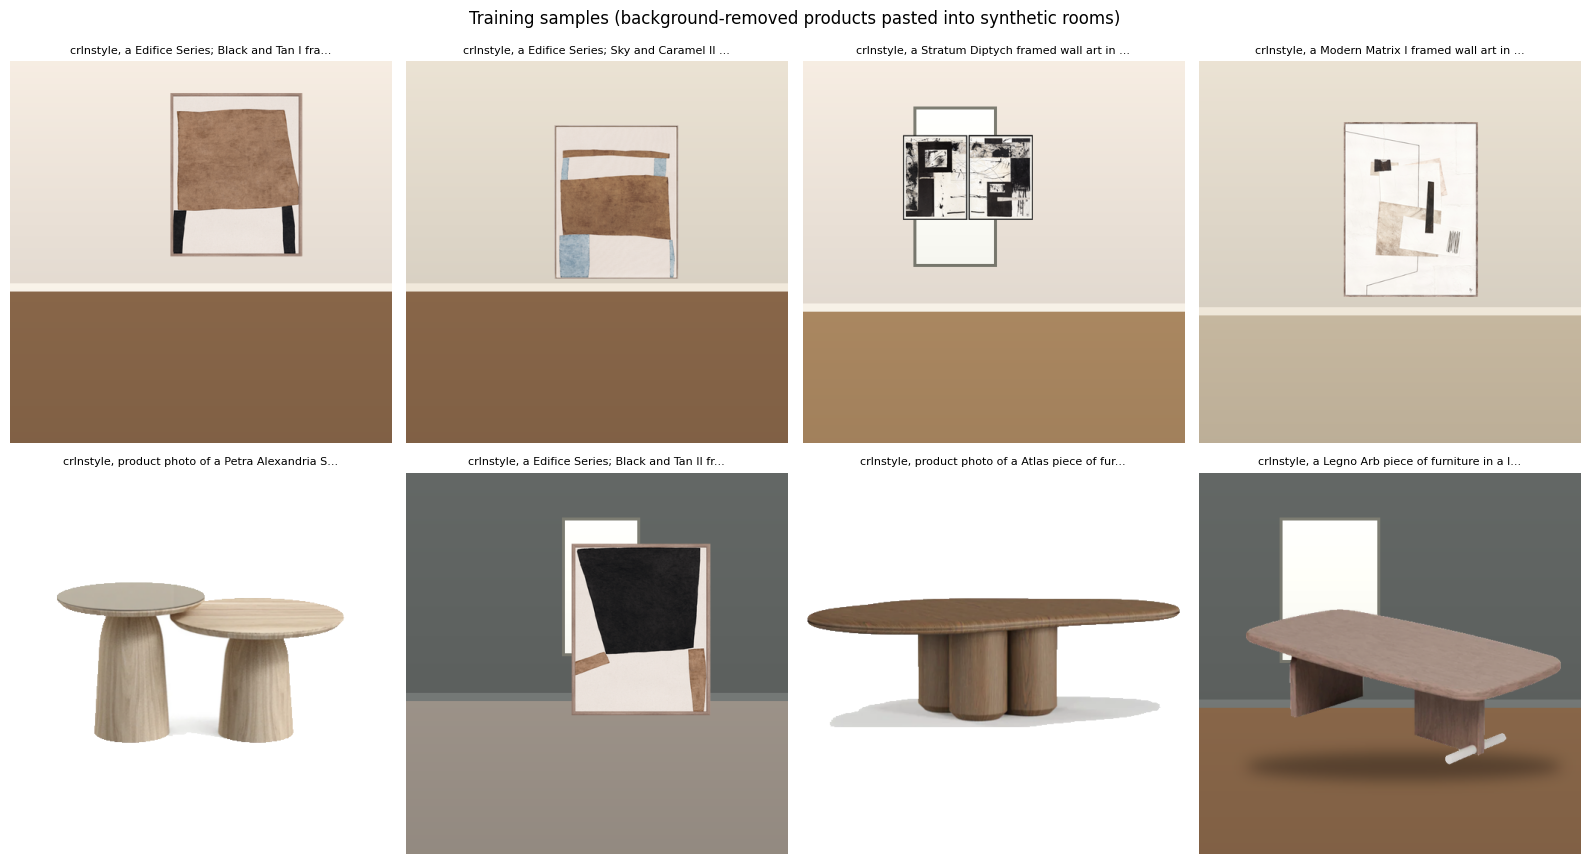

In [6]:
import matplotlib.pyplot as plt

rng_preview = random.Random(SEED)
sample_rows = df.sample(min(8, len(df)), random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, (_, row) in zip(axes.ravel(), sample_rows.iterrows()):
    img, cap = make_sample(row, rng_preview)
    ax.imshow(img); ax.axis("off"); ax.set_title(cap[:48] + "...", fontsize=8)
fig.suptitle("Training samples (background-removed products pasted into synthetic rooms)")
fig.tight_layout(); plt.show()


## 4. Load Stable Diffusion 1.5 and attach a LoRA

Everything except the small LoRA layers is frozen: the text encoder and VAE are only used to encode captions/images, and
the UNet's own weights don't change — only the low-rank adapter matrices added to its attention layers train. That is
why this fits on a free T4 and produces a file of a few MB.


In [7]:
# Upgrade torchao and peft to compatible versions
!pip install --upgrade torchao peft diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 36.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0
  Attempting uninstall: peft
    Found existing installation: peft 0.20.0
    Uninstalling peft-0.20.0:
      Successfully uninstalled peft-0.20.0


In [8]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel, StableDiffusionPipeline
from diffusers.optimization import get_scheduler
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from diffusers.utils import convert_state_dict_to_diffusers

if not torch.cuda.is_available():
    raise SystemExit("No GPU found. In Colab: Runtime > Change runtime type > T4 GPU, then run all again.")
device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

tokenizer = CLIPTokenizer.from_pretrained(BASE_MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(BASE_MODEL_ID, subfolder="text_encoder", torch_dtype=torch.float16).to(device)
vae = AutoencoderKL.from_pretrained(BASE_MODEL_ID, subfolder="vae", torch_dtype=torch.float16).to(device)
unet = UNet2DConditionModel.from_pretrained(BASE_MODEL_ID, subfolder="unet").to(device)   # fp32 master weights
noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL_ID, subfolder="scheduler")

text_encoder.requires_grad_(False); vae.requires_grad_(False); unet.requires_grad_(False)
unet.add_adapter(LoraConfig(r=LORA_RANK, lora_alpha=LORA_RANK, init_lora_weights="gaussian",
                            target_modules=["to_k", "to_q", "to_v", "to_out.0"]))
if GRADIENT_CHECKPOINTING:
    unet.enable_gradient_checkpointing()

lora_params = [p for p in unet.parameters() if p.requires_grad]
print(f"trainable LoRA parameters: {sum(p.numel() for p in lora_params):,} "
      f"(of {sum(p.numel() for p in unet.parameters()):,} total)")


class ProductRoomDataset(Dataset):
    def __init__(self, frame, size=RESOLUTION):
        self.rows = frame.to_dict("records"); self.size = size
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        rng = random.Random()                                    # fresh random room every time an image is seen
        try:
            image, caption = make_sample(self.rows[i], rng, self.size)
        except Exception:                                        # a bad file must never stop training
            return None
        pixels = torch.from_numpy(np.array(image, dtype=np.float32) / 127.5 - 1.0).permute(2, 0, 1)
        ids = tokenizer(caption, padding="max_length", max_length=tokenizer.model_max_length,
                        truncation=True, return_tensors="pt").input_ids[0]
        return {"pixel_values": pixels, "input_ids": ids}


def collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return None
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "input_ids": torch.stack([b["input_ids"] for b in batch])}


train_dl = DataLoader(ProductRoomDataset(df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate,
                      num_workers=2, drop_last=len(df) >= BATCH_SIZE)
optimizer = torch.optim.AdamW(lora_params, lr=LEARNING_RATE, weight_decay=1e-2)
lr_scheduler = get_scheduler("cosine", optimizer=optimizer, num_warmup_steps=50, num_training_steps=MAX_TRAIN_STEPS)
scaler = torch.amp.GradScaler("cuda")
print(f"{len(df)} images, {len(train_dl)} batches per epoch, {MAX_TRAIN_STEPS} steps "
      f"(~{MAX_TRAIN_STEPS / max(1, len(train_dl)):.1f} epochs)")


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


GPU: Tesla T4


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

unet/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

trainable LoRA parameters: 1,594,368 (of 861,115,332 total)
131 images, 65 batches per epoch, 1200 steps (~18.5 epochs)


## 5. Training loop

Same shape as your other notebooks — `zero_grad → forward → loss → backward → step` — with the diffusion-specific part
in the middle: encode the image to latents, add random noise at a random timestep, and train the UNet (via the LoRA
layers) to predict that noise. Loss and learning rate are recorded for the plots below. The LoRA is checkpointed to
Drive every `SAVE_EVERY` steps.


In [9]:
def save_lora(path: Path):
    path.mkdir(parents=True, exist_ok=True)
    state = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
    StableDiffusionPipeline.save_lora_weights(save_directory=str(path), unet_lora_layers=state, safe_serialization=True)


losses, lrs = [], []
step = 0
unet.train()
t0 = time.time()
try:
    while step < MAX_TRAIN_STEPS:
        for batch in train_dl:
            if batch is None:
                continue
            pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
            input_ids = batch["input_ids"].to(device)

            with torch.no_grad():
                latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
                encoder_hidden_states = text_encoder(input_ids)[0]
            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            optimizer.zero_grad()
            with torch.autocast("cuda", dtype=torch.float16):
                noise_pred = unet(noisy_latents.float(), timesteps, encoder_hidden_states.float()).sample
            loss = F.mse_loss(noise_pred.float(), noise.float())
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(lora_params, 1.0)
            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step()

            step += 1
            losses.append(loss.item()); lrs.append(lr_scheduler.get_last_lr()[0])
            if step % 25 == 0:
                print(f"Step: {step}/{MAX_TRAIN_STEPS}, Loss: {np.mean(losses[-25:]):.4f}, "
                      f"LR: {lrs[-1]:.2e}, elapsed: {(time.time() - t0) / 60:.1f} min")
            if step % SAVE_EVERY == 0:
                save_lora(OUTPUT_DIR / f"checkpoint-{step}")
            if step >= MAX_TRAIN_STEPS:
                break
except KeyboardInterrupt:
    print("Interrupted - saving what has been trained so far.")

save_lora(OUTPUT_DIR / "final")
pd.DataFrame({"loss": losses, "lr": lrs}).to_csv(OUTPUT_DIR / "training_log.csv", index=False)
with open(OUTPUT_DIR / "training_config.json", "w") as f:
    json.dump(dict(base_model=BASE_MODEL_ID, trigger=TRIGGER, steps=step, rank=LORA_RANK, resolution=RESOLUTION,
                   batch_size=BATCH_SIZE, lr=LEARNING_RATE, images=int(len(df)),
                   suppliers=sorted(df["supplier"].unique().tolist())), f, indent=2)
print("saved LoRA to", OUTPUT_DIR / "final")


Step: 25/1200, Loss: 0.0355, LR: 5.00e-05, elapsed: 0.5 min
Step: 50/1200, Loss: 0.0525, LR: 1.00e-04, elapsed: 0.9 min
Step: 75/1200, Loss: 0.0346, LR: 9.99e-05, elapsed: 1.3 min
Step: 100/1200, Loss: 0.0485, LR: 9.95e-05, elapsed: 1.7 min
Step: 125/1200, Loss: 0.0495, LR: 9.90e-05, elapsed: 2.1 min
Step: 150/1200, Loss: 0.0432, LR: 9.81e-05, elapsed: 2.4 min
Step: 175/1200, Loss: 0.0523, LR: 9.71e-05, elapsed: 2.8 min
Step: 200/1200, Loss: 0.0440, LR: 9.59e-05, elapsed: 3.2 min
Step: 225/1200, Loss: 0.0330, LR: 9.44e-05, elapsed: 3.6 min
Step: 250/1200, Loss: 0.0288, LR: 9.27e-05, elapsed: 3.9 min
Step: 275/1200, Loss: 0.0416, LR: 9.08e-05, elapsed: 4.4 min
Step: 300/1200, Loss: 0.0379, LR: 8.88e-05, elapsed: 4.7 min
Step: 325/1200, Loss: 0.0206, LR: 8.65e-05, elapsed: 5.1 min
Step: 350/1200, Loss: 0.0383, LR: 8.41e-05, elapsed: 5.5 min
Step: 375/1200, Loss: 0.0291, LR: 8.16e-05, elapsed: 5.9 min
Step: 400/1200, Loss: 0.0318, LR: 7.88e-05, elapsed: 6.2 min
Step: 425/1200, Loss: 0.036

## 6. Loss and learning-rate plots

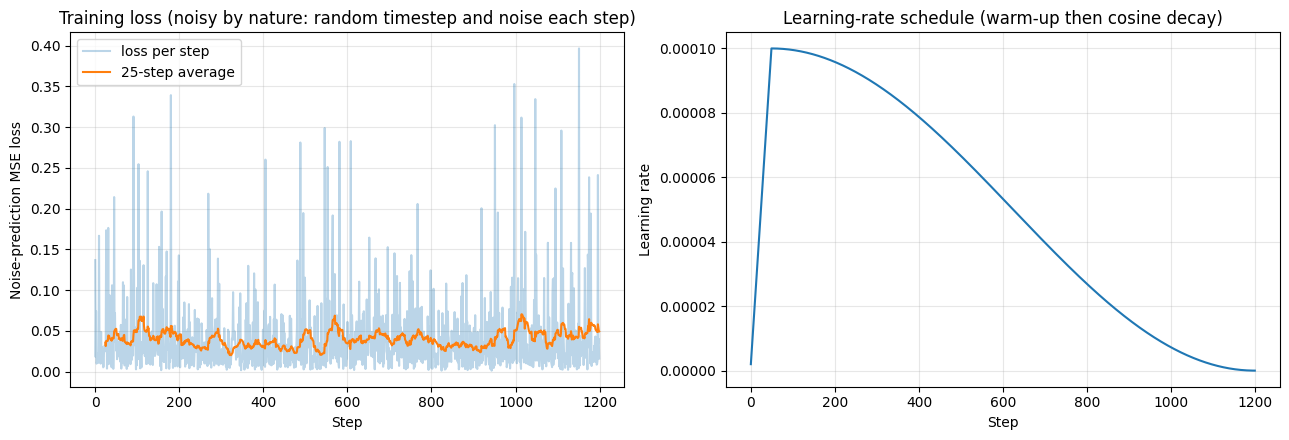

In [10]:
def moving_average(x, k=25):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(k) / k, mode="valid") if len(x) >= k else x

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(losses, alpha=0.3, label="loss per step")
axes[0].plot(np.arange(len(moving_average(losses))) + 24, moving_average(losses), label="25-step average")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Noise-prediction MSE loss")
axes[0].set_title("Training loss (noisy by nature: random timestep and noise each step)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(lrs); axes[1].set_xlabel("Step"); axes[1].set_ylabel("Learning rate")
axes[1].set_title("Learning-rate schedule (warm-up then cosine decay)"); axes[1].grid(True, alpha=0.3)
fig.tight_layout(); plt.show()


## 7. Save for download

The LoRA folder is already in `DRIVE_OUTPUT_DIR`. This also makes a single `.zip` next to it.


In [11]:
zip_path = shutil.make_archive(str(OUTPUT_DIR / "curalina_lora"), "zip", str(OUTPUT_DIR / "final"))
print("LoRA folder :", OUTPUT_DIR / "final")
print("zip         :", zip_path, f"({os.path.getsize(zip_path) / 1e6:.1f} MB)")
if IN_COLAB:
    print("In Drive, open the folder above and download curalina_lora.zip (or use the next line for a direct download).")
    # from google.colab import files; files.download(zip_path)


LoRA folder : /content/drive/MyDrive/curalina_lora_output/final
zip         : /content/drive/MyDrive/curalina_lora_output/curalina_lora.zip (6.0 MB)
In Drive, open the folder above and download curalina_lora.zip (or use the next line for a direct download).


## 8. Use it: plain model vs. model + your LoRA

Same prompts, same seeds, so the only difference is the LoRA. Include the trigger word (`crlnstyle`) in prompts for the
catalogue look. The first row is the plain SD 1.5 model; the second row is with your LoRA loaded.


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

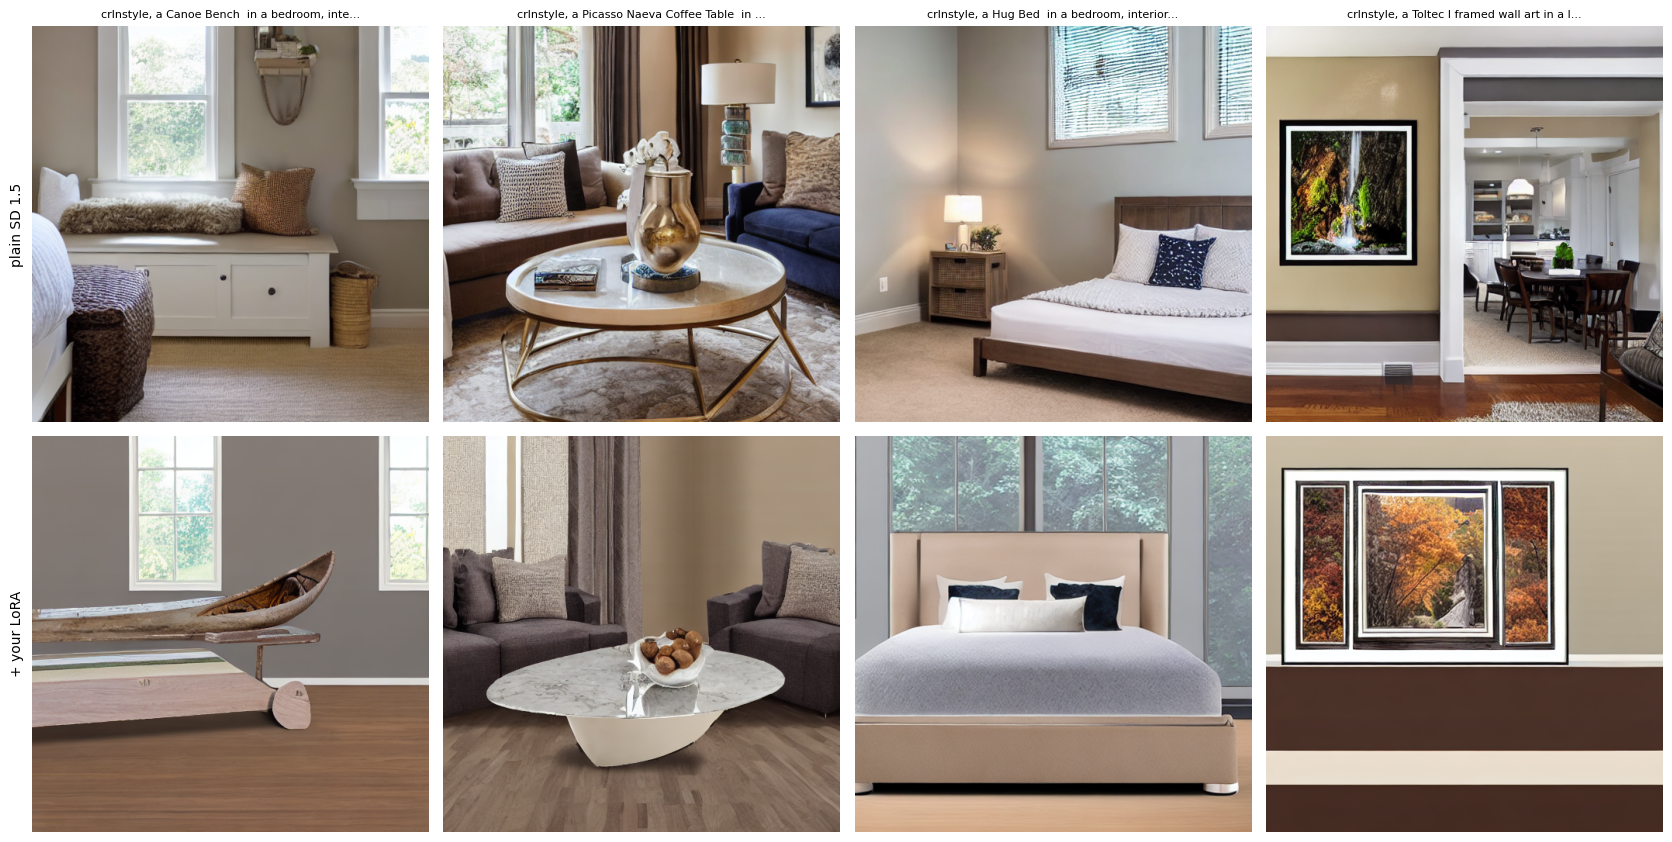

sample images saved to /content/drive/MyDrive/curalina_lora_output/samples


In [12]:
del unet, text_encoder, vae, optimizer
torch.cuda.empty_cache()

pipe = StableDiffusionPipeline.from_pretrained(BASE_MODEL_ID, torch_dtype=torch.float16, safety_checker=None).to("cuda")
pipe.set_progress_bar_config(disable=True)

names = df.sample(min(4, len(df)), random_state=7)
PROMPTS = [f"{TRIGGER}, a {r['name']} {r['category'] if r['category'] not in r['name'].lower() else ''} in a "
           f"{r['rooms'][0]}, interior design photo, natural light, high detail" for _, r in names.iterrows()]
NEGATIVE = "people, text, watermark, distorted furniture, low quality"
SEEDS = [11, 22, 33, 44][: len(PROMPTS)]


def generate(prompts, seeds):
    out = []
    for prompt, seed in zip(prompts, seeds):
        g = torch.Generator("cuda").manual_seed(seed)
        out.append(pipe(prompt, negative_prompt=NEGATIVE, num_inference_steps=25, guidance_scale=7.5, generator=g).images[0])
    return out


base_images = generate(PROMPTS, SEEDS)
pipe.load_lora_weights(str(OUTPUT_DIR / "final"))
lora_images = generate(PROMPTS, SEEDS)

fig, axes = plt.subplots(2, len(PROMPTS), figsize=(4.2 * len(PROMPTS), 8.6), squeeze=False)
for j, prompt in enumerate(PROMPTS):
    axes[0][j].imshow(base_images[j]); axes[0][j].axis("off"); axes[0][j].set_title(prompt[:44] + "...", fontsize=8)
    axes[1][j].imshow(lora_images[j]); axes[1][j].axis("off")
axes[0][0].text(-0.02, 0.5, "plain SD 1.5", transform=axes[0][0].transAxes, rotation=90, va="center", ha="right")
axes[1][0].text(-0.02, 0.5, "+ your LoRA", transform=axes[1][0].transAxes, rotation=90, va="center", ha="right")
fig.tight_layout(); plt.show()

samples_dir = OUTPUT_DIR / "samples"; samples_dir.mkdir(exist_ok=True)
for j, (a, b) in enumerate(zip(base_images, lora_images)):
    a.save(samples_dir / f"{j}_base.png"); b.save(samples_dir / f"{j}_lora.png")
print("sample images saved to", samples_dir)


## 9. Try your own prompt

Edit the prompt and re-run. Keep the trigger word for the catalogue look; describe the piece and the room.


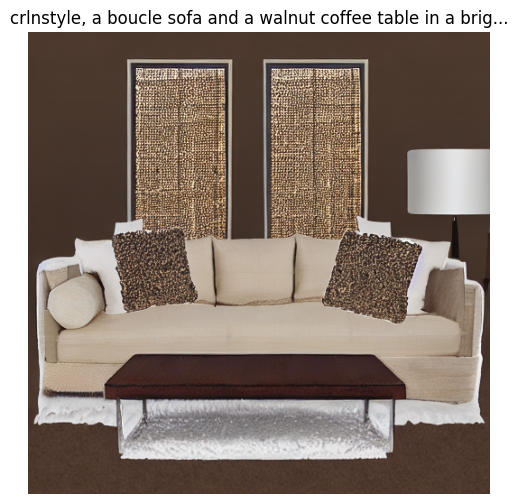

In [13]:
my_prompt = f"{TRIGGER}, a boucle sofa and a walnut coffee table in a bright living room, interior design photo, natural light"
g = torch.Generator("cuda").manual_seed(123)
image = pipe(my_prompt, negative_prompt=NEGATIVE, num_inference_steps=30, guidance_scale=7.5, generator=g).images[0]
plt.figure(figsize=(6, 6)); plt.imshow(image); plt.axis("off"); plt.title(my_prompt[:60] + "..."); plt.show()
image.save(OUTPUT_DIR / "samples" / "my_prompt.png")


## Using the result later

The LoRA is a standard `diffusers` LoRA (`pytorch_lora_weights.safetensors`). To use it in the Curalina SD service,
copy the `final` folder next to `ai_services/renderers/sd15/` and load it with `pipe.load_lora_weights(...)` in
`curalina_sd15/pipeline.py`'s `DiffusersPipelineFactory.build()` (a small change we can make when you're ready; the CPU
service would still take minutes per image, so the LoRA is best generated on a GPU for now).

**If results look weak:** raise `MAX_TRAIN_STEPS` (e.g. 2500) and re-run; lower `P_ROOM_BACKGROUND` if pieces look
pasted-on; check the training-sample grid in step 3 first — if those look wrong, the model will learn wrong.
